<a href="https://colab.research.google.com/github/jaffafritsch/DataVisualisationAssignment/blob/main/Copy_of_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Processing and Visualization
-----
**Assignment Topic: Data Analysis on Car Advertisements**


Student1 Name: Jarrah F.

SNumber: S5212509

Student2 Name: Aditya S.

SNumber: ...

Student3 Name: Grace T.

SNumber: s5407687





I've placed 1D earlier than its actual order since it makes the most sense to first normalise all strings to lower case prior to doing anything else

# Data Import, Tool Import and Variables

In [8]:
# Tool Import
import pandas, seaborn, sqlite3
import matplotlib.pyplot as plt

# Loads the initial Data sets into variables
dfCarData = pandas.read_csv("car_dataset.csv")
dfSellerData = pandas.read_csv("seller_dataset.csv")
dfCarData.rename(columns={"price (AUD)": "price"}, inplace=True)

# Functions

In [9]:
# First 3 functions are not used anymore but were previously part of my IDE script for testing, kept them in for reference but they are unused
# Prints first 5 rows of each dataset to check they loaded properly
def PrintFirst5():
    print(f"\nFirst 5 Rows of Car Dataset \n{dfCarData.head()}")
    print(f"\nFirst 5 Rows of Seller Dataset \n{dfSellerData.head()}\n\n")

# Function prints the duplicate count for both data sets
def CheckForDuplicates():
    print(f"\nFound {dfCarData.duplicated().sum()} duplicates in the car data")
    print(f"\nFound {dfSellerData.duplicated().sum()} duplicates in the seller data")

# Function prints the null count and columns with null counts + their count for both datasets
def CheckForNulls():
    carDataNullCount = dfCarData.isnull().sum().sum()
    sellerDataNullCount = dfSellerData.isnull().sum().sum()
    print(f"\nFound {carDataNullCount} null values in the car data \n")
    if carDataNullCount > 0:
        nulls = dfCarData.isnull().sum()
        print(nulls[nulls > 0].to_string())
    print(f"\nFound {sellerDataNullCount} null values in the seller data\n")
    if sellerDataNullCount > 0:
        nulls = dfSellerData.isnull().sum()
        print(nulls[nulls > 0].to_string())

# This function does the conversion by iterating through the column, extracting any numbers and then setting
# The value to the extracted numbers, due to the column having a Dtype of str initially i cast it as object so that it doesnt
# Care what the actual type is then finally cast the column as an int64 - 64 bit integer
# Could have written it as a real function that takes in a dataframe and column name an returns the int but didnt find it
# Necessary for the assignment but would be a better approach if the dataset was variable or wanted a general function for it
def CarNumericalConversion():
    dfCarData["mileage"] = dfCarData["mileage"].astype("object")
    for i, value in dfCarData["mileage"].items():
        convertedNum = "".join(n for n in str(value) if n.isdigit())
        dfCarData.at[i, "mileage"] = int(convertedNum)
    dfCarData["mileage"] = dfCarData["mileage"].astype("Int64")
    dfCarData["num_of_doors"] = dfCarData["num_of_doors"].astype("object")
    for i, value in dfCarData["num_of_doors"].items():
        convertedNum = "".join(n for n in str(value) if n.isdigit())
        dfCarData.at[i, "num_of_doors"] = int(convertedNum)
    dfCarData["num_of_doors"] = dfCarData["num_of_doors"].astype("Int64")
    dfCarData["seating_capacity"] = dfCarData["seating_capacity"].astype("object")
    for i, value in dfCarData["seating_capacity"].items():
        convertedNum = "".join(n for n in str(value) if n.isdigit())
        dfCarData.at[i, "seating_capacity"] = int(convertedNum)
    dfCarData["seating_capacity"] = dfCarData["seating_capacity"].astype("Int64")

    dfCarData["fuel_consumption"] = dfCarData["fuel_consumption"].astype("object")
    for i, value in dfCarData["fuel_consumption"].items():
        convertedNum = "".join(n for n in str(value).split("/")[0] if n.isdigit())
        dfCarData.at[i, "fuel_consumption"] = int(convertedNum) if convertedNum else pandas.NA
    dfCarData["fuel_consumption"] = dfCarData["fuel_consumption"].astype("Int64")


    print(dfCarData.head())
    dfCarData.info()

def EngineFeatureSplit():
    dfCarData.insert(loc=10, column="type_of_engine", value=None)
    dfCarData.insert(loc=11, column="engine_capacity", value=None)

    for i in dfCarData.index:
        engineValue = dfCarData.at[i, "engine"]
        engineCapacity = "".join(n for n in str(engineValue) if n.isdigit() or n == ".")
        engineCapacity = float(engineCapacity) if engineCapacity else None
        dfCarData.at[i, "engine_capacity"] = engineCapacity
        if str(engineValue).lower().__contains__("petrol"):
            dfCarData.at[i, "type_of_engine"] = "Petrol"
        elif str(engineValue).lower().__contains__("diesel"):
            dfCarData.at[i, "type_of_engine"] = "Diesel"
        elif str(engineValue).lower().__contains__("hybrid"):
            dfCarData.at[i, "type_of_engine"] = "Hybrid"
        elif str(engineValue).lower().__contains__("electric"):
            dfCarData.at[i, "type_of_engine"] = "Electric"
        else:
            dfCarData.at[i, "type_of_engine"] = "Unknown"
    dfCarData["engine_capacity"] = dfCarData["engine_capacity"].astype("float")
    dfCarData["type_of_engine"] = dfCarData["type_of_engine"].astype("str")
    print(dfCarData.head(10))
    dfCarData.info()


def HotEncode():
    # We do a check first to see if the column exists if not create it --> was mainly used during testing to repeatedly run this function and check outputs for ordering otherwise just creating without a check works
    if "origin_code" not in dfCarData.columns:         dfCarData.insert(loc=2, column="origin_code", value=None)
    if "condition_code" not in dfCarData.columns:      dfCarData.insert(loc=4, column="condition_code", value=None)
    if "car_model_code" not in dfCarData.columns:      dfCarData.insert(loc=6, column="car_model_code", value=None)
    if "exterior_color_code" not in dfCarData.columns: dfCarData.insert(loc=9, column="exterior_color_code", value=None)
    if "interior_color_code" not in dfCarData.columns: dfCarData.insert(loc=11, column="interior_color_code", value=None)
    if "type_of_engine_code" not in dfCarData.columns: dfCarData.insert(loc=16, column="type_of_engine_code", value=None)
    if "fuel_system_code" not in dfCarData.columns:    dfCarData.insert(loc=19, column="fuel_system_code", value=None)
    if "transmission_code" not in dfCarData.columns:   dfCarData.insert(loc=21, column="transmission_code", value=None)
    if "drive_type_code" not in dfCarData.columns:     dfCarData.insert(loc=23, column="drive_type_code", value=None)
    if "brand_code" not in dfCarData.columns:          dfCarData.insert(loc=26, column="brand_code", value=None)
    if "grade_code" not in dfCarData.columns:          dfCarData.insert(loc=28, column="grade_code", value=None)

    # We then create the encoded value for each column using pandas functions
    dfCarData["origin_code"] = dfCarData["origin"].astype("category").cat.codes
    dfCarData["condition_code"] = dfCarData["condition"].astype("category").cat.codes
    dfCarData["car_model_code"] = dfCarData["car_model"].astype("category").cat.codes
    dfCarData["exterior_color_code"] = dfCarData["exterior_color"].astype("category").cat.codes
    dfCarData["interior_color_code"] = dfCarData["interior_color"].astype("category").cat.codes
    dfCarData["type_of_engine_code"] = dfCarData["type_of_engine"].astype("category").cat.codes
    dfCarData["fuel_system_code"] = dfCarData["fuel_system"].astype("category").cat.codes
    dfCarData["transmission_code"] = dfCarData["transmission"].astype("category").cat.codes
    dfCarData["drive_type_code"] = dfCarData["drive_type"].astype("category").cat.codes
    dfCarData["brand_code"] = dfCarData["brand"].astype("category").cat.codes
    dfCarData["grade_code"] = dfCarData["grade"].astype("category").cat.codes

    # we then create dicts to map these values so we can convert between the code and label
    origin_decoder = dfCarData[["origin_code", "origin"]].drop_duplicates().set_index("origin_code")["origin"].to_dict()
    condition_decoder = dfCarData[["condition_code", "condition"]].drop_duplicates().set_index("condition_code")["condition"].to_dict()
    model_decoder = dfCarData[["car_model_code", "car_model"]].drop_duplicates().set_index("car_model_code")["car_model"].to_dict()
    exterior_color_decoder = dfCarData[["exterior_color_code", "exterior_color"]].drop_duplicates().set_index("exterior_color_code")["exterior_color"].to_dict()
    interior_color_decoder = dfCarData[["interior_color_code", "interior_color"]].drop_duplicates().set_index("interior_color_code")["interior_color"].to_dict()
    engine_type_decoder = dfCarData[["type_of_engine_code", "type_of_engine"]].drop_duplicates().set_index("type_of_engine_code")["type_of_engine"].to_dict()
    fuel_system_decoder = dfCarData[["fuel_system_code", "fuel_system"]].drop_duplicates().set_index("fuel_system_code")["fuel_system"].to_dict()
    transmission_decoder = dfCarData[["transmission_code", "transmission"]].drop_duplicates().set_index("transmission_code")["transmission"].to_dict()
    drive_decoder = dfCarData[["drive_type_code", "drive_type"]].drop_duplicates().set_index("drive_type_code")["drive_type"].to_dict()
    brand_decoder = dfCarData[["brand_code", "brand"]].drop_duplicates().set_index("brand_code")["brand"].to_dict()
    grade_decoder = dfCarData[["grade_code", "grade"]].drop_duplicates().set_index("grade_code")["grade"].to_dict()

    # Print all the decoders for reference
    print(f"Origin Decoder \n {dict(sorted(origin_decoder.items()))}")
    print(f"Condition Decoder \n {dict(sorted(condition_decoder.items()))}")
    print(f"Model Decoder \n {dict(sorted(model_decoder.items()))}")
    print(f"Exteriror Color Decoder \n {dict(sorted(exterior_color_decoder.items()))}")
    print(f"Interiror Color Decoder \n {dict(sorted(interior_color_decoder.items()))}")
    print(f"Engine Type Decoder \n {dict(sorted(engine_type_decoder.items()))}")
    print(f"Fuel System Decoder \n {dict(sorted(fuel_system_decoder.items()))}")
    print(f"Transmission Decoder \n {dict(sorted(transmission_decoder.items()))}")
    print(f"Drive Decoder \n {dict(sorted(drive_decoder.items()))}")
    print(f"Brand Decoder \n {dict(sorted(brand_decoder.items()))}")
    print(f"Grade Decoder \n {dict(sorted(grade_decoder.items()))}")

    # Print a sample of the data plus the dataframe info
    print(dfCarData.head(10))
    dfCarData.info()



def StandardiseText():
    for col in dfCarData.select_dtypes(include=["string"]).columns:
        dfCarData[col] = dfCarData[col].str.lower()
    print(dfCarData.head(10))
    dfCarData.info()


def NormaliseNumericalValues():
    columns = ["engine_capacity", "num_of_doors", "seating_capacity", "fuel_consumption", "price"]

    for col in columns:
        min_val = dfCarData[str(col)].min()
        max_val = dfCarData[str(col)].max()
        columName = col + "_minmax_normalised"
        dfCarData[str(columName)] = (dfCarData[col] - min_val) / (max_val - min_val)

    print(dfCarData.head(10))
    dfCarData.info()


def StoreToSQLDatabase():
    # Establishes a connection to the sqlite databases
    # Wanted 2 copies incase other non requested data could be useful for display
    # so we have 2 tables
    # Car Data - the full set
    # Car Data Refined - the requested data
    conn = sqlite3.connect("database.db")
    cur = conn.cursor()


    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = [row[0] for row in cur.fetchall()]
    for t in tables:
        cur.execute(f'DELETE FROM "{t}"')
    conn.commit()

    dfCarData.to_sql("Car Data", conn, if_exists="append", index=False)
    dfSellerData.to_sql("Seller Data", conn, if_exists="append", index=False)
    table = "Car Data Refined"
    cur.execute(f'PRAGMA table_info("{table}")')
    db_cols = [row[1] for row in cur.fetchall()]
    matched_cols = [c for c in dfCarData.columns if c in db_cols]
    dfCarData[matched_cols].to_sql(table, conn, if_exists="append", index=False)
    conn.close()




# Data Formatting

## 1D

In [10]:
StandardiseText()

    ad_id             origin condition    car_model mileage exterior_color  \
0   17042  Domestic assembly   New car        Truck    0 Km          White   
1   53794           Imported   New car          SUV    0 Km          Black   
2   73954  Domestic assembly   New car    Crossover    0 Km         Silver   
3   74150           Imported   New car          SUV    0 Km          White   
4   87573  Domestic assembly   New car    Crossover    0 Km         Silver   
5   97011  Domestic assembly   New car  Van/Minivan    0 Km          White   
6  101726  Domestic assembly   New car          SUV    0 Km          White   
7  135739           Imported   New car          SUV    0 Km         Copper   
8  142495  Domestic assembly   New car          4x4    0 Km           Grey   
9  143308  Domestic assembly   New car          4x4    0 Km          Black   

  interior_color num_of_doors seating_capacity         engine  \
0           gray       2-door           2-seat  Petrol\t1.0 L   
1          

## 1A

In [11]:
CarNumericalConversion()

   ad_id             origin condition  car_model  mileage exterior_color  \
0  17042  Domestic assembly   New car      Truck        0          White   
1  53794           Imported   New car        SUV        0          Black   
2  73954  Domestic assembly   New car  Crossover        0         Silver   
3  74150           Imported   New car        SUV        0          White   
4  87573  Domestic assembly   New car  Crossover        0         Silver   

  interior_color  num_of_doors  seating_capacity         engine fuel_system  \
0           gray             2                 2  Petrol\t1.0 L         NaN   
1          Black             5                 7  Petrol\t3.4 L         NaN   
2          Brown             5                 8  Petrol\t2.0 L         NaN   
3          Black             5                 5  Petrol\t1.8 L         NaN   
4           gray             5                 8  Petrol\t2.0 L         NaN   

  transmission                 drive_type  fuel_consumption   brand 

## 1B

In [12]:
EngineFeatureSplit()

    ad_id             origin condition    car_model  mileage exterior_color  \
0   17042  Domestic assembly   New car        Truck        0          White   
1   53794           Imported   New car          SUV        0          Black   
2   73954  Domestic assembly   New car    Crossover        0         Silver   
3   74150           Imported   New car          SUV        0          White   
4   87573  Domestic assembly   New car    Crossover        0         Silver   
5   97011  Domestic assembly   New car  Van/Minivan        0          White   
6  101726  Domestic assembly   New car          SUV        0          White   
7  135739           Imported   New car          SUV        0         Copper   
8  142495  Domestic assembly   New car          4x4        0           Grey   
9  143308  Domestic assembly   New car          4x4        0          Black   

  interior_color  num_of_doors  seating_capacity         engine  ...  \
0           gray             2                 2  Petrol\t

## 1C

In [13]:
HotEncode()

Origin Decoder 
 {0: 'Domestic assembly', 1: 'Imported'}
Condition Decoder 
 {0: 'New car', 1: 'Used car'}
Model Decoder 
 {0: '4x4', 1: 'Convertible/Cabriolet', 2: 'Coupe', 3: 'Crossover', 4: 'Hatchback', 5: 'SUV', 6: 'Sedan', 7: 'Truck', 8: 'Van/Minivan', 9: 'Wagon'}
Exteriror Color Decoder 
 {0: '-', 1: 'Black', 2: 'Brown', 3: 'Colorful', 4: 'Copper', 5: 'Cream', 6: 'Different color', 7: 'Green', 8: 'Grey', 9: 'Orange', 10: 'Pink', 11: 'Red', 12: 'Sand', 13: 'Silver', 14: 'Take note', 15: 'Violet', 16: 'White', 17: 'Yellow'}
Interiror Color Decoder 
 {0: '-', 1: 'Black', 2: 'Brown', 3: 'Colorful', 4: 'Copper', 5: 'Cream', 6: 'Different color', 7: 'Green', 8: 'Grey', 9: 'Orange', 10: 'Pink', 11: 'Red', 12: 'Sand', 13: 'Silver', 14: 'Violet', 15: 'White', 16: 'Yellow', 17: 'gray'}
Engine Type Decoder 
 {0: 'Diesel', 1: 'Electric', 2: 'Hybrid', 3: 'Petrol', 4: 'Unknown'}
Fuel System Decoder 
 {-1: nan, 0: ' 1.5L', 1: ' 2.0 turbo', 2: ' 2.0L i4 TDCi Bi-Turbo Diesel engine', 3: ' 2.4LE',

## 1E

In [14]:
NormaliseNumericalValues()

    ad_id             origin  origin_code condition  condition_code  \
0   17042  Domestic assembly            0   New car               0   
1   53794           Imported            1   New car               0   
2   73954  Domestic assembly            0   New car               0   
3   74150           Imported            1   New car               0   
4   87573  Domestic assembly            0   New car               0   
5   97011  Domestic assembly            0   New car               0   
6  101726  Domestic assembly            0   New car               0   
7  135739           Imported            1   New car               0   
8  142495  Domestic assembly            0   New car               0   
9  143308  Domestic assembly            0   New car               0   

     car_model  car_model_code  mileage exterior_color  exterior_color_code  \
0        Truck               7        0          White                   16   
1          SUV               5        0          Black      

# Data Exploration and Cleaning

## 2A: Statistics Computation

In [15]:
# ---------- 2A: Statistics Computation ----------
# Providing mean, median, mode, standard deviation and range
# for 'price', 'mileage' and 'year_of_manufacture'. describe() gives neither mode nor
# range, so we build the table ourselves.

def ComputeStatistics(columns=None, label=""):
    if columns is None:
        columns = ["price", "mileage", "year_of_manufacture"]

    rows = []
    for col in columns:
        series = pandas.to_numeric(dfCarData[col], errors="coerce").dropna()
        modeValues = series.mode()
        rows.append({
            "variable": col,
            "count": series.count(),
            "mean": series.mean(),
            "median": series.median(),
            "mode": modeValues.iloc[0] if not modeValues.empty else pandas.NA,
            "std_dev": series.std(),
            "min": series.min(),
            "max": series.max(),
            "range": series.max() - series.min(),
            "skew": series.skew(),
        })

    statsTable = pandas.DataFrame(rows).set_index("variable")
    print(f"Basic statistics {label}\n")
    print(statsTable.to_string(float_format=lambda v: f"{v:,.2f}"))
    return statsTable


statsBefore = ComputeStatistics(label="(before cleaning)")

Basic statistics (before cleaning)

                     count       mean    median      mode       std_dev      min              max            range   skew
variable                                                                                                                 
price                30652  42,843.16 24,939.33 40,485.92     78,585.59     0.00     2,186,239.69     2,186,239.69   8.68
mileage              30652 412,315.03 20,000.00      0.00 34,899,663.67     0.00 4,294,967,295.00 4,294,967,295.00 121.68
year_of_manufacture  30620   2,017.32  2,019.00  2,023.00          5.33 1,990.00         2,023.00            33.00  -1.30


### 2A — Interpretation

| variable | mean | median | mode | std dev | range |
|---|---|---|---|---|---|
| price | 42,843.16 | 24,939.33 | 40,485.92 | 78,585.59 | 0 – 2,186,239.69 |
| mileage | 412,315.03 | 20,000.00 | 0.00 | 34,899,663.67 | 0 – 4,294,967,295 |
| year_of_manufacture | 2,017.32 | 2,019.00 | 2,023.00 | 5.33 | 1990 – 2023 |

**price** — the mean sits roughly 72% above the median and the skew is +8.68, so the
distribution has a long right tail. A small number of luxury and commercial vehicles
priced above AUD 1,000,000 drag the mean upward, which means the **median (AUD 24,939)
is the more representative "typical" car** in this market. The mode of AUD 40,485.92
repeating exactly tells us prices were converted from another currency at a fixed rate,
producing repeated values rather than a smooth distribution.

**mileage** — the mean of 412,315 km is more than twenty times the median of 20,000 km,
and the standard deviation (34.9 million) is larger than any odometer could physically
record. The maximum is exactly **4,294,967,295 = 2³² − 1**, the largest value an unsigned
32-bit integer can hold. This is a data-corruption sentinel, not a measurement, and it
alone is responsible for most of the inflated mean and standard deviation. The mode of 0 km
reflects the large share of new cars in the dataset (around 20% of listings).

**year_of_manufacture** — negatively skewed (−1.30) with a median of 2019 and a mode of
2023. The dataset is dominated by recent stock, with a thin tail of older vehicles back
to 1990. The narrow standard deviation of 5.33 years confirms most advertisements are for
near-new cars, which is worth remembering when interpreting the price analysis later: the
sample is not representative of the used market as a whole.

**Overall** — for both price and mileage the mean is badly distorted by extreme values,
so median and IQR are the appropriate summary measures for this dataset, and any
normalisation must happen *after* the impossible values have been dealt with.

## 2B(i): Outlier Detection (IQR method)

IQR outlier summary:

                        Q1        Q3       IQR  lower_bound  upper_bound  n_outliers  pct_outliers  min              max
variable                                                                                                                
price            16,396.80 40,445.43 24,048.64   -19,676.16    76,518.39        3767         12.29 0.00     2,186,239.69
mileage               0.00 60,000.00 60,000.00   -90,000.00   150,000.00        1050          3.43 0.00 4,294,967,295.00
engine_capacity       1.50      2.40      0.90         0.15         3.75        1076          3.67 0.10            12.70
num_of_doors          4.00      5.00      1.00         2.50         6.50         769          2.51 0.00            54.00
seating_capacity      5.00      7.00      2.00         2.00        10.00         225          0.73 0.00            47.00
fuel_consumption      6.00      8.00      2.00         3.00        11.00         577          5.05 0.00       200,000.00


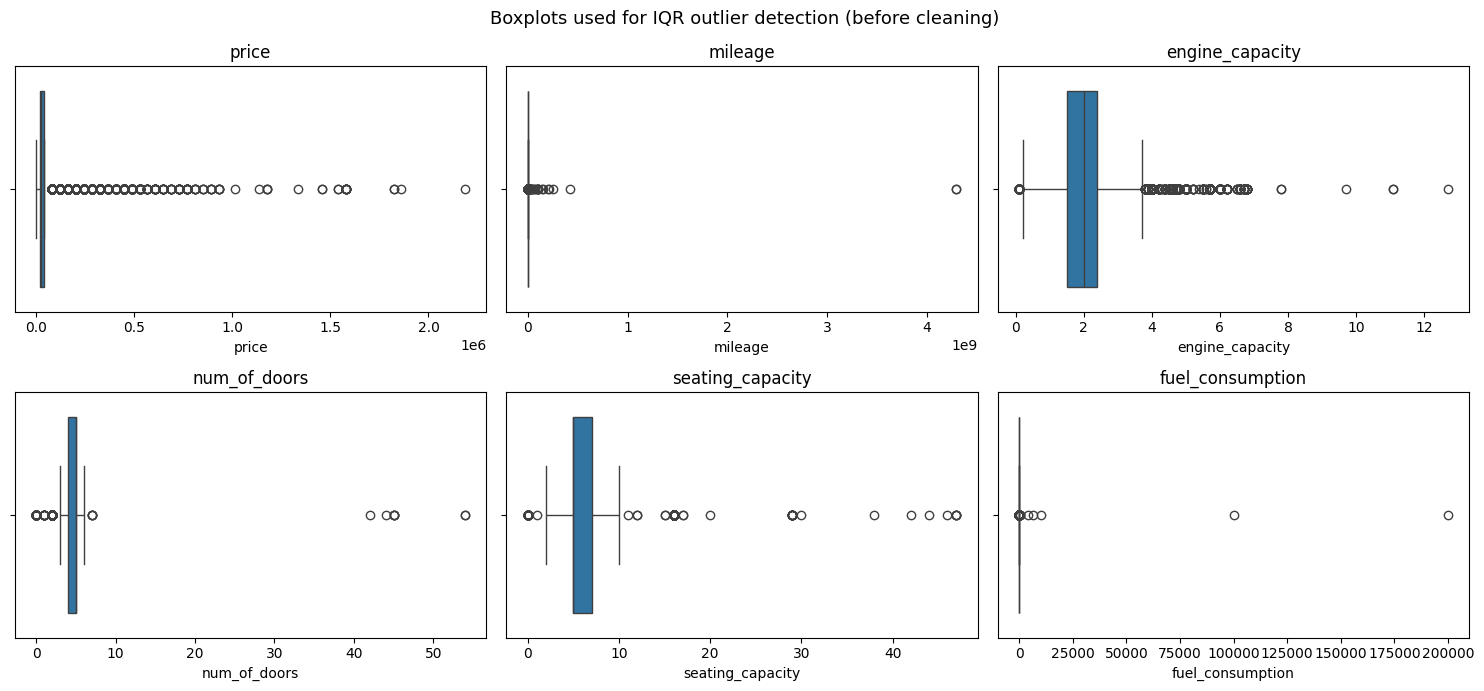


--- Supporting evidence ---
Mileage above 1,000,000 km      : 124
Mileage equal to 4,294,967,295  : 2   <- 2^32 - 1 sentinel
Doors outside the range 2-7     : 89
Seating capacity above 20       : 21
Fuel consumption above 30       : 50
Price below AUD 1,000           : 174

The implausible prices only take a handful of distinct values:
price
0.008097      44
0.000041      31
0.004049      23
0.003239      21
0.002024      14
0.000081      14
0.001215      10
0.000162       8
0.000121       7
728.746562     1
850.204322     1


In [19]:
# ---------- 2B(i): Outlier detection using the IQR method ----------

def DetectOutliersIQR(columns=None, showPlots=True):
    if columns is None:
        columns = ["price", "mileage", "engine_capacity",
                   "num_of_doors", "seating_capacity", "fuel_consumption"]

    rows = []
    for col in columns:
        series = pandas.to_numeric(dfCarData[col], errors="coerce")
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lowerBound = q1 - 1.5 * iqr
        upperBound = q3 + 1.5 * iqr
        mask = (series < lowerBound) | (series > upperBound)
        rows.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lowerBound,
            "upper_bound": upperBound,
            "n_outliers": int(mask.sum()),
            "pct_outliers": round(mask.sum() / series.notna().sum() * 100, 2),
            "min": series.min(),
            "max": series.max(),
        })

    outlierTable = pandas.DataFrame(rows).set_index("variable")
    print("IQR outlier summary:\n")
    print(outlierTable.to_string(float_format=lambda v: f"{v:,.2f}"))

    if showPlots:
        fig, axes = plt.subplots(2, 3, figsize=(15, 7))
        for ax, col in zip(axes.flatten(), columns):
            seaborn.boxplot(x=pandas.to_numeric(dfCarData[col], errors="coerce"), ax=ax)
            ax.set_title(f"{col}")
            ax.set_xlabel(col)
        fig.suptitle("Boxplots used for IQR outlier detection (before cleaning)", fontsize=13)
        plt.tight_layout()
        plt.show()

    return outlierTable


outliersBefore = DetectOutliersIQR()

# Evidence for the decisions discussed in the text cell below
print("\n--- Supporting evidence ---")
print(f"Mileage above 1,000,000 km      : {(dfCarData['mileage'] > 1_000_000).sum()}")
print(f"Mileage equal to 4,294,967,295  : {(dfCarData['mileage'] == 4_294_967_295).sum()}   <- 2^32 - 1 sentinel")
print(f"Doors outside the range 2-7     : {(~dfCarData['num_of_doors'].between(2, 7)).sum()}")
print(f"Seating capacity above 20       : {(dfCarData['seating_capacity'] > 20).sum()}")
print(f"Fuel consumption above 30       : {(dfCarData['fuel_consumption'] > 30).sum()}")
print(f"Price below AUD 1,000           : {(dfCarData['price'] < 1000).sum()}")
print("\nThe implausible prices only take a handful of distinct values:")
print(dfCarData.loc[dfCarData['price'] < 1000, 'price'].value_counts().to_string())

### 2B(i) — Outlier decisions and justification

The IQR method flags anything below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. Flagging is
mechanical, but the decision of what to do next is not: an outlier can be a genuine
observation, a recording error, or a corrupted value, and each needs different treatment.
Our decision for each variable:

| variable | outliers | decision | justification |
|---|---|---|---|
| price | 3,767 (12.29%) | **Retain** | These are real luxury and commercial vehicles (Porsche, Lexus, Land Cruiser). Deleting 12% of the data would remove an entire legitimate market segment and bias every conclusion about what drives price downward. The skew is a property of the car market, not an error. |
| mileage | 1,050 (3.43%) | **Split decision** | Values between 150,000 and 1,000,000 km are high but achievable for an older vehicle, so they are **retained**. The 124 rows above 1,000,000 km — including two at exactly 2³² − 1 — are physically impossible and are **transformed to NA and imputed**. |
| engine_capacity | 1,076 (3.67%) | **Retain** | The maximum of 12.7 L is large for a passenger car but entirely normal for the trucks in this dataset. These are real engines, so they stay. |
| num_of_doors | 769 (2.51%) | **Transform** | 69 cars with 0 doors and 8 with 42–54 doors are data entry errors. Set to NA and imputed from the mode of the same car_model. |
| seating_capacity | 225 (0.73%) | **Split decision** | 16 and 20 seats are genuine for vans and minibuses and are **retained**; anything above 20 (max 47) is **transformed**. |
| fuel_consumption | 577 (5.05%) | **Split decision** | The IQR upper bound of 11.0 L/100 km is too aggressive here — large 4WDs and trucks genuinely use 12–20 L/100 km, so those values are **retained**. Only readings above 30 L/100 km are **transformed**, including a maximum of 200,000 L/100 km that is physically impossible. This variable is the clearest demonstration that the IQR test flags candidates, but domain knowledge decides the treatment. |

We also found a separate problem the IQR method does **not** flag, because the values sit
at the *bottom* of the range where the lower bound is negative: **174 advertisements with
a price below AUD 1,000**, some as low as AUD 0.00004. These fall into only 11 distinct
values, and when compared against other listings of the same `car_name` they are
consistently the correct price divided by either 10⁶ or 10⁹ — a unit-scaling corruption.
Because the scale factor is not consistent between the two groups we cannot reliably
repair them, and `price` is the variable the entire analysis is trying to explain.
Imputing the target variable would manufacture the very relationship we are trying to
measure, so these rows are **removed** rather than transformed.

The guiding principle throughout: **remove only when the row is unusable and the value
cannot be recovered, transform when the value is impossible but the rest of the row is
sound, and retain when the value is merely extreme.**

## 2B(ii): Missing Values and Data Cleaning

In [20]:
# ---------- 2B(ii): Treating invalid values and missing values ----------

rowsBefore = len(dfCarData)
missingBefore = dfCarData.isnull().sum()

def FlagImpossibleValues():
    """Domain-validity caps. Values that are physically impossible are set to NA so
    they can be imputed, rather than deleting the whole advertisement."""
    flagged = {}

    rules = {
        "mileage":          dfCarData["mileage"] > 1_000_000,
        "num_of_doors":     ~dfCarData["num_of_doors"].between(2, 7),
        "seating_capacity": ~dfCarData["seating_capacity"].between(1, 20),
        "fuel_consumption": (dfCarData["fuel_consumption"] > 30) | (dfCarData["fuel_consumption"] <= 0),
        "engine_capacity":  (dfCarData["engine_capacity"] > 13) | (dfCarData["engine_capacity"] <= 0),
    }

    for col, mask in rules.items():
        mask = mask.fillna(False)
        flagged[col] = int(mask.sum())
        dfCarData.loc[mask, col] = pandas.NA

    print("Values set to NA because they are physically impossible:")
    for col, n in flagged.items():
        print(f"  {col:<18}: {n}")
    return flagged


def RecoverYearFromCarName():
    """32 rows have no year_of_manufacture, but the year is present at the end of
    'car_name' (e.g. 'toyota vios e cvt 2022'). Recovering the real value is always
    preferable to imputing an average."""
    missingMask = dfCarData["year_of_manufacture"].isna()
    extracted = dfCarData.loc[missingMask, "car_name"].str.extract(r"(19[89]\d|20[0-2]\d)")[0]
    recovered = extracted.notna().sum()
    dfCarData.loc[missingMask, "year_of_manufacture"] = pandas.to_numeric(extracted, errors="coerce")
    print(f"\nyear_of_manufacture: recovered {recovered} of {missingMask.sum()} missing values from 'car_name'.")


def GroupImpute(column, groupCols, method="median"):
    """Impute within a group first (cars of the same model behave alike), then fall
    back to the overall statistic for anything the group could not fill."""
    originalDtype = dfCarData[column].dtype
    series = pandas.to_numeric(dfCarData[column], errors="coerce").astype("float64")
    naBefore = int(series.isna().sum())

    if method == "median":
        groupValue = series.groupby([dfCarData[c] for c in groupCols]).transform("median")
        filled = series.fillna(groupValue).fillna(series.median())
    else:
        groupValue = series.groupby([dfCarData[c] for c in groupCols]).transform(
            lambda s: s.mode().iloc[0] if not s.mode().empty else float("nan"))
        filled = series.fillna(groupValue).fillna(series.mode().iloc[0])

    # Counts such as doors and seats must stay whole numbers
    if str(originalDtype).startswith("Int"):
        filled = filled.round().astype(originalDtype)

    dfCarData[column] = filled
    print(f"  {column:<20}: {naBefore} missing -> {int(dfCarData[column].isna().sum())} missing "
          f"({method} within {' + '.join(groupCols)})")


def HandleMissingValues():
    print("\nImputation:")

    # Numeric, continuous and strongly model-dependent -> group median.
    # The median is used rather than the mean because all of these are right-skewed.
    GroupImpute("engine_capacity",  ["brand", "car_model"], "median")
    # A large share of fuel_consumption is missing, so we keep a flag marking which
    # values are real and which were filled, for any later analysis that needs it.
    dfCarData["fuel_consumption_was_imputed"] = dfCarData["fuel_consumption"].isna()
    GroupImpute("fuel_consumption", ["car_model", "type_of_engine"], "median")
    GroupImpute("mileage",          ["car_model", "condition"], "median")

    # Discrete counts -> mode. A car cannot have 4.7 doors, so an average is meaningless.
    GroupImpute("num_of_doors",     ["car_model"], "mode")
    GroupImpute("seating_capacity", ["car_model"], "mode")

    # A brand new car with no odometer reading is genuinely 0 km, not unknown.
    newCarMask = dfCarData["condition"].str.contains("new", case=False, na=False)
    dfCarData.loc[newCarMask & dfCarData["mileage"].isna(), "mileage"] = 0

    # 78% of fuel_system is missing. Imputing a single mode across 23,910 rows would
    # invent a variable rather than repair one, so it is kept as an explicit category.
    fuelSystemMissing = dfCarData["fuel_system"].isna().sum()
    dfCarData["fuel_system"] = dfCarData["fuel_system"].fillna("unknown")
    print(f"  {'fuel_system':<20}: {fuelSystemMissing} missing -> labelled 'unknown' (not imputed)")

    # Any remaining year gaps fall back to the median year.
    dfCarData["year_of_manufacture"] = dfCarData["year_of_manufacture"].fillna(
        dfCarData["year_of_manufacture"].median())


def DropUnusableRows():
    """price is the variable the whole analysis is trying to explain. Imputing the
    target would manufacture the very relationship we intend to measure, so rows with
    an impossible price are removed instead."""
    global dfCarData
    badPriceMask = dfCarData["price"] < 1000
    removed = int(badPriceMask.sum())
    dfCarData = dfCarData.loc[~badPriceMask].reset_index(drop=True)
    print(f"\nRemoved {removed} advertisements with an impossible price (< AUD 1,000).")


FlagImpossibleValues()
RecoverYearFromCarName()
HandleMissingValues()
DropUnusableRows()

# ---------- Before / after comparison ----------
print("\n" + "=" * 60)
print(f"Before cleaning data: {rowsBefore} rows")
print(f"After cleaning data : {len(dfCarData)} rows  "
      f"({rowsBefore - len(dfCarData)} removed, "
      f"{(rowsBefore - len(dfCarData)) / rowsBefore * 100:.2f}%)")
print("=" * 60)

comparison = pandas.DataFrame({
    "missing_before": missingBefore,
    "missing_after": dfCarData.isnull().sum(),
})
print("\nMissing values before and after:\n")
print(comparison[comparison.sum(axis=1) > 0].to_string())

print("\nStatistics after cleaning (compare with 2A):\n")
statsAfter = ComputeStatistics(label="(after cleaning)")

print("\nIQR summary after cleaning:\n")
outliersAfter = DetectOutliersIQR(showPlots=False)

Values set to NA because they are physically impossible:
  mileage           : 124
  num_of_doors      : 89
  seating_capacity  : 76
  fuel_consumption  : 78
  engine_capacity   : 0

year_of_manufacture: recovered 32 of 32 missing values from 'car_name'.

Imputation:
  engine_capacity     : 1367 missing -> 0 missing (median within brand + car_model)
  fuel_consumption    : 19294 missing -> 0 missing (median within car_model + type_of_engine)
  mileage             : 124 missing -> 0 missing (median within car_model + condition)
  num_of_doors        : 89 missing -> 0 missing (mode within car_model)
  seating_capacity    : 76 missing -> 0 missing (mode within car_model)
  fuel_system         : 23910 missing -> labelled 'unknown' (not imputed)

Removed 174 advertisements with an impossible price (< AUD 1,000).

Before cleaning data: 30652 rows
After cleaning data : 30478 rows  (174 removed, 0.57%)

Missing values before and after:

                                    missing_before  missi

### 2B(ii) — Missing value treatment and justification

| variable | missing | % | method | justification |
|---|---|---|---|---|
| fuel_system | 23,910 | 78.0% | **Labelled `"unknown"`, not imputed** | With more than three quarters of the column absent, imputing the mode would assign one invented value to 23,910 cars and create a variable that looks complete but carries no information. Treating "not stated" as its own category is honest and keeps the rows usable for the other analyses. |
| fuel_consumption | 19,216 | 62.7% | **Median within car_model + type_of_engine** | The source values are literally `"L/100Km"` with no number, so the data is missing at the point of entry rather than at random. Fuel consumption is tightly determined by body type and engine type, so a group median is far better than a global one. Because the share is high we also keep a `fuel_consumption_was_imputed` flag so imputed rows can be excluded from any analysis that depends on this variable. |
| engine_capacity | 1,367 | 4.5% | **Median within brand + car_model** | These rows have an engine listed as just `"Diesel"` with no litre figure. Engine size is consistent within a model, so the group median recovers a close estimate. The median rather than the mean because the variable is right-skewed. |
| year_of_manufacture | 32 | 0.1% | **Recovered from `car_name`** | Not imputed at all. The manufacture year appears at the end of nearly every car name (e.g. `"toyota vios e cvt 2022"`), so a regular expression recovers all 32 real values. Recovering a true value is always preferable to estimating one. |
| num_of_doors, seating_capacity | created by 2B(i) | — | **Mode within car_model** | These are discrete counts. A mean of 4.7 doors is not a car that exists, so the mode is the only sensible statistic, taken within car_model because a hatchback and a truck have different typical door counts. |
| mileage | created by 2B(i) | — | **0 for new cars, else median within car_model + condition** | A brand new car genuinely has 0 km on the odometer, so that value is known rather than missing. For used cars the median within model and condition is used. |

**Result of cleaning**

Before cleaning data: **30,652 rows**. After cleaning data: **30,478 rows** (174 removed, 0.57%).

Only the 174 unrecoverable-price rows were deleted. Everything else was repaired in place,
which preserves 99.4% of the sample. The effect on the summary statistics is substantial:

| variable | mean before | mean after | std dev before | std dev after |
|---|---|---|---|---|
| mileage | 412,315.03 | 40,004.63 | 34,899,663.67 | 69,457.71 |
| price | 42,843.16 | 43,087.70 | 78,585.59 | 78,742.73 |

Mileage now behaves like a real odometer reading: the mean falls by 90% and the standard
deviation by nearly three orders of magnitude, and the maximum drops from 4,294,967,295 km
to 1,000,000 km. Price barely moves, which confirms that the price outliers we chose to
retain are genuine listings rather than corruption — exactly the outcome our justification
predicted. The IQR re-run after cleaning shows the same pattern: price still has 3,767
outliers because those cars are real, while seating_capacity falls from 225 to 148 and its
maximum from 47 to 20.

> **Note on ordering:** min-max normalisation from task 1E must be re-run *after* this cell.
> The "missing values before and after" table above still shows 1,351 gaps in
> `engine_capacity_minmax_normalised` and 19,113 in `fuel_consumption_minmax_normalised`,
> because those columns were scaled before the underlying values were repaired. Worse, a
> single mileage value of 4,294,967,295 sets `max_val` and compresses every real car to
> approximately 0.000005. Cleaning first and scaling second is what makes the preprocessing
> workflow reproducible.

# Data Storage

## 3: Store to the Database

In [16]:
StoreToSQLDatabase()

OperationalError: near ")": syntax error

## 3: Queries

In [ ]:
conn = sqlite3.connect("database.db")
dfCarSummary = pandas.read_sql("SELECT * FROM car_summary", conn)
print(dfCarSummary.head(10))


# Data Visualisation